### Import data 🌸˚˖𓍢ִ໋🌷͙֒✧🩷˚⋆

In [28]:
import pandas as pd
import numpy as np

inf = pd.read_csv('../data/inf.csv', header=0, index_col=None)
occ = pd.read_csv('../data/occupancy.csv', header=0, index_col=0)
duration = pd.read_csv('../data/duration.csv', header=0, index_col=0)
volume = pd.read_csv('../data/volume.csv', header=0, index_col=0)
e_price = pd.read_csv('../data/e_price.csv', index_col=0, header=0).values
s_price = pd.read_csv('../data/s_price.csv', index_col=0, header=0).values
adj = pd.read_csv('../data/adj.csv', header=0, index_col=None)
weather = pd.read_csv('../data/weather_central.csv',header=0,index_col='time')

In [29]:
#STUB - import adj and preprocess:
import torch
adj = np.array(adj)
adj_dense  = torch.Tensor(adj)
adj_dense.shape[0]

275

### Process data 🌸˚˖𓍢ִ໋🌷͙֒✧🩷˚⋆

In [30]:
occ

,102,104,105,106,107,108,109,110,111,115,...,1156,1159,1162,1163,1164,1166,1167,1168,1172,1173
time,,,,,,,,,,,,,,,,,,,,,
9/1/2022 0:00,17,1.0,15.0,54.0,23.0,13,11.0,6.0,20.0,3.0,...,10.0,31.0,9,2.0,45.0,26.0,183,17.0,2,10.0
9/1/2022 1:00,16,1.0,19.0,50.0,25.0,13,7.0,12.0,19.0,3.0,...,7.0,31.0,8,1.0,42.0,25.0,174,12.0,2,9.0
9/1/2022 2:00,16,1.0,20.0,44.0,24.0,16,12.0,6.0,21.0,3.0,...,7.0,38.0,9,2.0,48.0,24.0,196,13.0,2,12.0
9/1/2022 3:00,16,1.0,20.0,44.0,22.0,16,12.0,6.0,21.0,3.0,...,7.0,38.0,9,2.0,48.0,24.0,187,13.0,2,13.0
9/1/2022 4:00,17,1.0,20.0,50.0,24.0,13,8.0,12.0,20.0,3.0,...,7.0,31.0,8,1.0,42.0,25.0,167,11.0,2,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/28/2023 19:00,10,2.0,15.0,43.0,13.0,12,6.0,9.0,12.0,2.0,...,4.0,37.0,2,5.0,33.0,22.0,145,8.0,3,9.0
2/28/2023 20:00,13,2.0,16.0,43.0,16.0,14,8.0,9.0,13.0,2.0,...,4.0,38.0,3,5.0,30.0,23.0,171,10.0,4,10.0
2/28/2023 21:00,14,2.0,16.0,44.0,18.0,13,7.0,10.0,14.0,2.0,...,3.0,36.0,7,5.0,34.0,27.0,183,10.0,4,10.0


### Build Tensor data 🌸˚˖𓍢ִ໋🌷͙֒✧🩷˚⋆

In [31]:
occ_numpy = occ.to_numpy( dtype = np.float32)

In [32]:
occ_tensor_conv1d = torch.tensor(occ_numpy ,dtype=torch.float32)
occ_tensor_conv1d.shape

torch.Size([4344, 275])

In [33]:
train_raw_conv1d = occ_tensor_conv1d[:3040]
val_raw_conv1d   = occ_tensor_conv1d[3040:3692]
test_raw_conv1d  = occ_tensor_conv1d[3692:]

In [34]:
def build_seq_data_conv1d(data, seq_len=12, pred_len=1):
    # data: (T, nodes)
    X = []
    y = []

    T = data.shape[1] # data input có shape là (4434,275). Lấy shape [1] là lấy 275

    for t in range(T - seq_len - pred_len + 1):
        x_seq = data[t : t + seq_len]              # (seq, nodes, features)
        y_target = data[t + seq_len, :]         # occupancy next step: (nodes,)

        X.append(x_seq)
        y.append(y_target)

    X = torch.stack(X)   # (samples, seq, nodes, features)
    y = torch.stack(y)   # (samples, nodes)

    # đổi sang (samples, nodes, seq)
    X = X.permute(0, 2, 1)

    return X, y

In [35]:
X_train_conv1d, y_train_conv1d = build_seq_data_conv1d(train_raw_conv1d, seq_len=12)

print(X_train_conv1d.shape)
print(y_train_conv1d.shape)

torch.Size([263, 275, 12])
torch.Size([263, 275])


In [36]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch

# X_train: [num_samples, N, T, F]
# y_train: [num_samples, N]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

num_samples, N, T = X_train_conv1d.shape

X_train_conv1d_scaled = x_scaler.fit_transform(X_train_conv1d.reshape(-1, 1)).reshape(num_samples, N, T)

y_train_conv1d_scaled = y_scaler.fit_transform(y_train_conv1d.reshape(-1, 1)).reshape(y_train_conv1d.shape)

X_train_conv1d_scaled = torch.tensor(X_train_conv1d_scaled, dtype=torch.float32)
y_train_conv1d_scaled = torch.tensor(y_train_conv1d_scaled, dtype=torch.float32)

train_data_scale_conv1d = TensorDataset(X_train_conv1d_scaled,y_train_conv1d_scaled)

train_data_scale_conv1d_loader = DataLoader(train_data_scale_conv1d,batch_size=32,shuffle=True)

In [37]:
X_train_conv1d, y_train_conv1d = build_seq_data_conv1d(train_raw_conv1d, seq_len=12)

# print(X_train_conv1d)
# print(y_train_conv1d.shape)

In [38]:
train_conv1d = TensorDataset(X_train_conv1d, y_train_conv1d)
train_conv1d_loader = DataLoader(train_conv1d, batch_size = 32, shuffle = False)
print(type(train_conv1d_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [39]:
X_test_conv1d, y_test_conv1d = build_seq_data_conv1d(test_raw_conv1d, seq_len=12)

# print(X_train_conv1d)
# print(y_train_conv1d.shape)

In [40]:
num_samples, N, T = X_test_conv1d.shape

X_test_conv1d_scaled = x_scaler.fit_transform(X_test_conv1d.reshape(-1, 1)).reshape(num_samples, N, T)

y_test_conv1d_scaled = y_scaler.fit_transform(y_test_conv1d.reshape(-1, 1)).reshape(y_test_conv1d.shape)

X_test_conv1d_scaled = torch.tensor(X_test_conv1d_scaled, dtype=torch.float32)
y_test_conv1d_scaled = torch.tensor(y_test_conv1d_scaled, dtype=torch.float32)

test_data_scale_conv1d = TensorDataset(X_test_conv1d_scaled,y_test_conv1d_scaled)

test_data_scale_conv1d_loader = DataLoader(test_data_scale_conv1d,batch_size=32,shuffle=False)

In [41]:
X_val_conv1d, y_val_conv1d = build_seq_data_conv1d(val_raw_conv1d, seq_len=12)

print(X_train_conv1d.shape)
# print(y_train_conv1d.shape)

torch.Size([263, 275, 12])


In [42]:
num_samples, N, T = X_val_conv1d.shape

X_val_conv1d_scaled = x_scaler.fit_transform(X_val_conv1d.reshape(-1, 1)).reshape(num_samples, N, T)

y_val_conv1d_scaled = y_scaler.fit_transform(y_val_conv1d.reshape(-1, 1)).reshape(y_val_conv1d.shape)

X_val_conv1d_scaled = torch.tensor(X_val_conv1d_scaled, dtype=torch.float32)
y_val_conv1d_scaled = torch.tensor(y_val_conv1d_scaled, dtype=torch.float32)

val_data_scale_conv1d = TensorDataset(X_val_conv1d_scaled,y_val_conv1d_scaled)

val_data_scale_conv1d_loader = DataLoader(val_data_scale_conv1d,batch_size=32,shuffle=False)

In [43]:
val_conv1d = TensorDataset(X_val_conv1d, y_val_conv1d)
val_conv1d_loader = DataLoader(val_conv1d, batch_size = 32, shuffle = False)
print(type(val_conv1d_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [44]:
for x,y in train_data_scale_conv1d_loader:
    print (x.shape)
    print(y.shape)
    break

torch.Size([32, 275, 12])
torch.Size([32, 275])


### Models 🌸🦢🌷✨💗⋆

In [45]:
import torch.nn as nn
class GCN_Conv1D(nn.Module):
    def __init__(self, sequence, n_features, output_dimension,adj_dense, hidden_dimension = 32):
        super().__init__()
        self.nodes = adj_dense.shape[0]
        self.input_dimension = sequence
        self.n_features = n_features
        self.output_dimension = output_dimension
        self.hidden_dimension = hidden_dimension
        self.activation_function = nn.ReLU()
        self.encoder = nn.Conv1d(self.nodes, self.nodes, 1)
        # input.shape: [batch, feature, length]
        # torch.Size([32, 275, 12])
        # Calculate A_delta matrix (normalized adjacency)
        deg = torch.sum(adj_dense, dim=0)
        deg = torch.diag(deg)
        deg_delta = torch.linalg.inv(torch.sqrt(deg))
        a_delta = torch.matmul(torch.matmul(deg_delta, adj_dense),  deg_delta)
        self.A = a_delta
        
        #Define GCN layers:
        self.gcn_layer_list = nn.ModuleList()
        self.gcn_layer_list.append(nn.Linear(self.input_dimension, self.hidden_dimension))
        self.gcn_layer_list.append(nn.Linear(self.hidden_dimension, self.hidden_dimension))
        self.decoder = nn.Linear(self.hidden_dimension+self.input_dimension,1) #giữ lại data input
        
    def forward(self, x):
        x = self.encoder(x)
        batch_size, node,  seq_len = x.size()
        x = x.squeeze(-1)
        gcn_out = x.squeeze(-1)
        
        for gcn_layer in self.gcn_layer_list:
            gcn_out = gcn_layer(gcn_out)
            gcn_out = torch.matmul(self.A, gcn_out)
            gcn_out = self.activation_function(gcn_out)
            
        combined_output = torch.cat((x,gcn_out),dim = -1)
        x = self.decoder(combined_output)
        gcn_out = torch.squeeze(x)
        
        return gcn_out

In [46]:
model_TSGCNConv1D = GCN_Conv1D(sequence = 12, n_features = 3, output_dimension =1, adj_dense = adj_dense)

#### 🦢 ARIMA 

In [47]:
arima_data = occ
arima_data

,102,104,105,106,107,108,109,110,111,115,...,1156,1159,1162,1163,1164,1166,1167,1168,1172,1173
time,,,,,,,,,,,,,,,,,,,,,
9/1/2022 0:00,17,1.0,15.0,54.0,23.0,13,11.0,6.0,20.0,3.0,...,10.0,31.0,9,2.0,45.0,26.0,183,17.0,2,10.0
9/1/2022 1:00,16,1.0,19.0,50.0,25.0,13,7.0,12.0,19.0,3.0,...,7.0,31.0,8,1.0,42.0,25.0,174,12.0,2,9.0
9/1/2022 2:00,16,1.0,20.0,44.0,24.0,16,12.0,6.0,21.0,3.0,...,7.0,38.0,9,2.0,48.0,24.0,196,13.0,2,12.0
9/1/2022 3:00,16,1.0,20.0,44.0,22.0,16,12.0,6.0,21.0,3.0,...,7.0,38.0,9,2.0,48.0,24.0,187,13.0,2,13.0
9/1/2022 4:00,17,1.0,20.0,50.0,24.0,13,8.0,12.0,20.0,3.0,...,7.0,31.0,8,1.0,42.0,25.0,167,11.0,2,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2/28/2023 19:00,10,2.0,15.0,43.0,13.0,12,6.0,9.0,12.0,2.0,...,4.0,37.0,2,5.0,33.0,22.0,145,8.0,3,9.0
2/28/2023 20:00,13,2.0,16.0,43.0,16.0,14,8.0,9.0,13.0,2.0,...,4.0,38.0,3,5.0,30.0,23.0,171,10.0,4,10.0
2/28/2023 21:00,14,2.0,16.0,44.0,18.0,13,7.0,10.0,14.0,2.0,...,3.0,36.0,7,5.0,34.0,27.0,183,10.0,4,10.0


In [48]:
import numpy as np
import warnings
from tqdm import tqdm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

class ARIMABaseline:
    def __init__(self, p=12, d=1, q=1, train_ratio=0.7, val_ratio=0.15):
        self.p = p
        self.d = d
        self.q = q
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio

    def fit_predict(self, data):
        if hasattr(data, "values"):
            data = data.values.astype(float)
        else:
            data = np.asarray(data).astype(float)

        n = len(data)
        train_end = int(n * self.train_ratio)
        val_end = int(n * (self.train_ratio + self.val_ratio))

        train_data = data[:train_end, :]   # dùng train + val để fit
        test_data  = data[val_end:, :]   # test thật

        T_test, num_nodes = test_data.shape
        preds = np.zeros((T_test, num_nodes))
    
        for j in tqdm(range(num_nodes)):
            series = train_data[:, j]

            try:
                model = ARIMA(series, order=(self.p, self.d, self.q))
                model_fit = model.fit()
                preds[:, j] = model_fit.forecast(steps=T_test)
            except Exception as e:
                print(f"ARIMA failed at node {j}: {e}")
                preds[:, j] = series[-1]

        mse = mean_squared_error(test_data.flatten(), preds.flatten())
        mae = mean_absolute_error(test_data.flatten(), preds.flatten())
        rmse = np.sqrt(mse)

        return preds, test_data, mse, mae, rmse

In [49]:
# arima_model = ARIMABaseline(p=12, d=1, q=1)

# arima_preds, arima_test, arima_mse, arima_mae, arima_rmse = arima_model.fit_predict(arima_data)

# print("Prediction shape:", arima_preds.shape)
# print("Test shape:", arima_test.shape)
# print("MSE:", arima_mse)
# print("MAE:", arima_mae)
# print("RMSE:", arima_rmse)

In [50]:
!pip install pmdarima


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import numpy as np
import warnings
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pmdarima import auto_arima
class AutoARIMABaseline:
    def __init__(
        self,
        train_ratio=0.7,
        val_ratio=0.15,
        max_p=12,
        max_d=2,
        max_q=3,
        seasonal=False,
        m=1
    ):
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.max_p = max_p
        self.max_d = max_d
        self.max_q = max_q
        self.seasonal = seasonal
        self.m = m
        self.orders = {}

    def fit_predict(self, data):
        if hasattr(data, "values"):
            data = data.values.astype(float)
        else:
            data = np.asarray(data).astype(float)

        n = len(data)
        train_end = int(n * self.train_ratio)
        val_end = int(n * (self.train_ratio + self.val_ratio))

        # Nên dùng train + validation để fit baseline cuối cùng
        train_data = data[:val_end, :]
        test_data = data[val_end:, :]

        T_test, num_nodes = test_data.shape
        preds = np.zeros((T_test, num_nodes))

        warnings.filterwarnings("ignore")

        for j in tqdm(range(num_nodes)):
            series = train_data[:, j]

            try:
                model = auto_arima(
                    series,
                    start_p=0,
                    start_q=0,
                    max_p=self.max_p,
                    max_d=self.max_d,
                    max_q=self.max_q,
                    d=None,
                    seasonal=self.seasonal,
                    m=self.m,
                    stepwise=True,
                    suppress_warnings=True,
                    error_action="ignore",
                    trace=False
                )

                preds[:, j] = model.predict(n_periods=T_test)

                # Lưu lại order được chọn cho từng trạm
                self.orders[j] = model.order

            except Exception as e:
                print(f"AutoARIMA failed at node {j}: {e}")
                preds[:, j] = series[-1]
                self.orders[j] = None

        mask = ~np.isnan(preds)

        mse = mean_squared_error(test_data[mask], preds[mask])
        mae = mean_absolute_error(test_data[mask], preds[mask])
        rmse = np.sqrt(mse)

        return preds, test_data, mse, mae, rmse

In [52]:
auto_arima_model = AutoARIMABaseline(train_ratio=0.7,val_ratio=0.15,max_p=12,max_d=2,max_q=3,seasonal=False)

auto_preds, auto_test, auto_mse, auto_mae, auto_rmse = auto_arima_model.fit_predict(arima_data)

print("MSE:", auto_mse)
print("MAE:", auto_mae)
print("RMSE:", auto_rmse)

100%|██████████| 275/275 [2:51:28<00:00, 37.41s/it]   

MSE: 128.11857783558145
MAE: 6.564912163791461
RMSE: 11.318947735349848


In [53]:
from statsmodels.tsa.ar_model import AutoReg
class Ar:
    def __init__(self, pred_len, lags=12,train_ratio=0.7, val_ratio=0.15):
        """
        Initialize the AR model parameters.

        Args:
            lags (int): The number of lagged observations to use in the model.
        """
        self.pred_len = pred_len
        self.lags = lags
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        
    def fit_predict(self, data):
        if hasattr(data, "values"):
            data = data.values.astype(float)
        else:
            data = np.asarray(data).astype(float)

        n = len(data)
        train_end = int(n * self.train_ratio)
        val_end = int(n * (self.train_ratio + self.val_ratio))

        train_data = data[:train_end, :]   # dùng train + val để fit
        test_data  = data[val_end:, :]   # test thật

        T_test, num_nodes = test_data.shape
        preds = np.zeros((T_test, num_nodes))

        for j in tqdm(range(num_nodes)):
            series = list(train_data[:, j])
            for i in range(T_test):
                try:
                    model = AutoReg(series, lags=self.lags).fit()
                    pred = model.predict(start=len(series), end=len(series))
                    preds[i, j] = pred[0]
                    series.append(pred[0])  # 滚动加入预测值
                except Exception as e:
                    print(f"[AutoReg] Failed at node {j}, step {i}: {e}")
                    preds[i, j] = np.nan

        mse = mean_squared_error(test_data.flatten(), preds.flatten())
        mae = mean_absolute_error(test_data.flatten(), preds.flatten())
        rmse = np.sqrt(mse)

        return preds, test_data, mse, mae, rmse

In [54]:
# autoreg_model = Ar(1,lags=12,train_ratio=0.7, val_ratio=0.15)
# autoreg_preds,autoreg_test, autoreg_mse,autoreg_mae,autoreg_rmse = autoreg_model.fit_predict(arima_data)
# print("Prediction shape:", autoreg_preds.shape)
# print("Test shape:", autoreg_test.shape)
# print("MSE:", autoreg_mse)
# print("MAE:", autoreg_mae)
# print("RMSE:", autoreg_rmse)

### Models training and Compare ˖°𓇼🌊⋆🐚🫧

In [55]:
import torch.nn.functional as F

def metric(pred, target):

    mae = F.l1_loss(pred, target)

    mse = F.mse_loss(pred, target)

    rmse = torch.sqrt(mse)

    mape = (torch.mean(torch.abs((target - pred) / (target + 1e-8))) * 100)

    return mae.item(), rmse.item(), mape.item()

#### 🌊 Conv1D

In [56]:
import matplotlib.pyplot as plt

In [57]:
%%time
optimizer = torch.optim.Adam(model_TSGCNConv1D.parameters(),lr=1e-3)
train_loss_list_1D = []
val_loss_list_1D = []

for epoch in range(50):
    model_TSGCNConv1D.train()
    train_loss = 0

    for x, y in train_data_scale_conv1d_loader:
        pred = model_TSGCNConv1D(x)
        loss = F.mse_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_data_scale_conv1d_loader)
    train_loss_list_1D.append(train_loss)
    
    # Validation after each epoch
    model_TSGCNConv1D.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_val, y_val in val_data_scale_conv1d_loader:
            pred_val = model_TSGCNConv1D(x_val)
            loss_val = F.mse_loss(pred_val, y_val)
            val_loss += loss_val.item()
            
    val_loss /= len(val_data_scale_conv1d_loader)
    val_loss_list_1D.append(val_loss)
    
    print(f"Epoch {epoch+1:02d} | Train MSE={train_loss:.4f} | Val MSE={val_loss:.4f}")

Epoch 01 | Train MSE=0.8675 | Val MSE=0.6971
Epoch 02 | Train MSE=0.5307 | Val MSE=0.4270
Epoch 03 | Train MSE=0.3147 | Val MSE=0.2921
Epoch 04 | Train MSE=0.2179 | Val MSE=0.2342
Epoch 05 | Train MSE=0.1662 | Val MSE=0.2152
Epoch 06 | Train MSE=0.1441 | Val MSE=0.2004
Epoch 07 | Train MSE=0.1300 | Val MSE=0.1917
Epoch 08 | Train MSE=0.1259 | Val MSE=0.1901
Epoch 09 | Train MSE=0.1183 | Val MSE=0.1855
Epoch 10 | Train MSE=0.1129 | Val MSE=0.1822
Epoch 11 | Train MSE=0.1161 | Val MSE=0.1800
Epoch 12 | Train MSE=0.1067 | Val MSE=0.1755
Epoch 13 | Train MSE=0.1044 | Val MSE=0.1753
Epoch 14 | Train MSE=0.1040 | Val MSE=0.1722
Epoch 15 | Train MSE=0.1032 | Val MSE=0.1692
Epoch 16 | Train MSE=0.0961 | Val MSE=0.1621
Epoch 17 | Train MSE=0.0924 | Val MSE=0.1613
Epoch 18 | Train MSE=0.0868 | Val MSE=0.1563
Epoch 19 | Train MSE=0.0841 | Val MSE=0.1572
Epoch 20 | Train MSE=0.0821 | Val MSE=0.1535
Epoch 21 | Train MSE=0.0766 | Val MSE=0.1505
Epoch 22 | Train MSE=0.0784 | Val MSE=0.1489
Epoch 23 |

In [58]:
model_TSGCNConv1D.eval()

y_true_list = []
y_pred_list = []

with torch.no_grad():
    for x_val, y_val in val_data_scale_conv1d_loader:
        pred_val = model_TSGCNConv1D(x_val)

        y_true_list.append(y_val.detach().cpu().numpy())
        y_pred_list.append(pred_val.detach().cpu().numpy())

# Gộp list thành numpy array
y_true_scaled = np.concatenate(y_true_list, axis=0)
y_pred_scaled = np.concatenate(y_pred_list, axis=0)

# Lưu lại shape gốc
y_true_shape = y_true_scaled.shape
y_pred_shape = y_pred_scaled.shape

# Inverse scale
y_original = y_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).reshape(y_true_shape)

pred_original = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_shape)

# Làm phẳng để tính RMSE
y_original_flat = y_original.reshape(-1)
pred_original_flat = pred_original.reshape(-1)

rmse = np.sqrt(np.mean((pred_original_flat - y_original_flat) ** 2))

print(f"Final RMSE = {rmse:.4f}")

Final RMSE = 7.8922


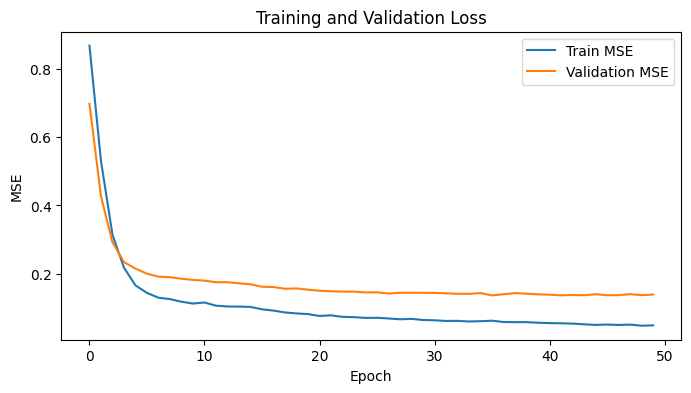

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(train_loss_list_1D, label="Train MSE")
plt.plot(val_loss_list_1D, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()